<a href="https://colab.research.google.com/github/a-mensah26/Akosua_Boateng-Mensah_Lab1/blob/main/Akosua_Boateng_Mensah_Lab_1A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [26]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [27]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [28]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [29]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        if state == self.goal:
          return True
        else:
          return False
        # Return True if state is equal to the goal state.
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        legal_actions =[]
        row,col = state
        for action in MOVES:
          [dr,dc] = MOVES[action]
          neighbour_cell = (row+dr,col+dc)
          if self.in_bounds(neighbour_cell):
            if self.is_free(neighbour_cell):
              legal_actions.append(action)
        return legal_actions
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row,col =state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        #raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0
        #raise NotImplementedError("Complete GridProblem.action_cost")

In [30]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [31]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [32]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()



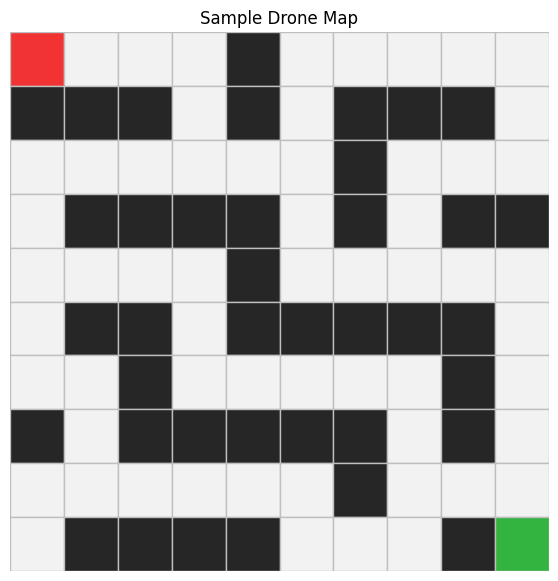

In [33]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [34]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
          s_prime = problem.result(s, action)
          cost = node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [35]:
# class BreadthFirstSearch(SearchAlgorithm):
#     def search(self, problem: Problem) -> SearchResult:
#         algorithm = "BFS"

#         # TODO 6:
#         # Implement BFS graph search using a FIFO queue.
#         initial_state = problem.initial_state()

#         node = Node(state=initial_state, parent=None, action=None, path_cost=0)
#         if problem.is_goal(node.state):
#           return node
#         frontier = deque([node])
#         reached = {initial_state}
#         while frontier:
#           node = frontier.popleft()
#           nodes_expanded += 1
#           for child in self.expand(problem, node):
#             if problem.is_goal(child.state):
#               return child
#             if child.state not in reached:
#               reached.add(child.state)
#               frontier.append(child)
#           max_frontier_size = max(max_frontier_size, len(frontier))
#         return child




#         # Steps:
#         # 1. Create the initial node from problem.initial_state().
#         # 2. If the initial state is the goal, return success.
#         # 3. Create a deque frontier and add the initial node.
#         # 4. Create a reached set and add the initial state.
#         # 5. While frontier is not empty:
#         #       a. pop from the LEFT of the deque.
#         #       b. increment nodes_expanded.
#         #       c. expand the node.
#         #       d. for each child:
#         #            i. if child is goal, return success.
#         #           ii. if child.state is not in reached:
#         #                  add child.state to reached.
#         #                  append child to frontier.
#         #       e. update max_frontier_size.
#         # 6. Return failure if no solution is found.
#         #
#         # Hint:
#         # frontier = deque([node])
#         # node = frontier.popleft()
#        # raise NotImplementedError("Complete BreadthFirstSearch.search")

In [36]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # Initialize metrics
        nodes_expanded = 0
        max_frontier_size = 0
        reached_count = 0

        initial_state = problem.initial_state()
        node = Node(state=initial_state, parent=None, action=None, path_cost=0)

        # Handle case where initial state is the goal
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=0,
                reached_count=1
            )

        frontier = deque([node])
        reached = {initial_state}
        reached_count = len(reached)
        max_frontier_size = len(frontier)

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    reached_count += 1
            max_frontier_size = max(max_frontier_size, len(frontier))

        # If the frontier is empty and no solution was found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

In [37]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        nodes_expanded = 0
        max_frontier_size = 0
        reached_count = 0

        initial_state = problem.initial_state()
        node = Node(state=initial_state, parent=None, action=None, path_cost=0)

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=0,
                reached_count=1 # Initial state is reached
            )

        frontier = [node] # Use a list as a stack
        reached = {initial_state}
        reached_count = len(reached) # Should be 1 after initial state
        max_frontier_size = len(frontier) # Should be 1 after initial node

        while frontier:
            node = frontier.pop() # Pop from the end (stack behavior)
            nodes_expanded += 1

            # Get children and reverse them to ensure specific order of exploration
            # (e.g., if MOVES are UP, DOWN, LEFT, RIGHT, then RIGHT will be explored first)
            children = list(self.expand(problem, node))
            children.reverse() # This ensures children from 'MOVES' are pushed in order and popped in reverse order of MOVES.

            for child in children:
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached) # Current size of reached set
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    reached_count += 1 # Increment only when a new state is reached

            max_frontier_size = max(max_frontier_size, len(frontier))

        # If the frontier is empty and no solution was found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached) # Final size of reached set
        )

In [38]:
# class BreadthFirstSearch(SearchAlgorithm):
#     def search(self, problem: Problem) -> SearchResult:
#         algorithm = "BFS"

#         # TODO 6:
#         # Implement BFS graph search using a FIFO queue.
#         initial_state = problem.initial_state()

#         node = Node(state=initial_state, parent=None, action=None, path_cost=0)
#         if problem.is_goal(node.state):
#           return node
#         frontier = deque([node])
#         reached = {initial_state}
#         while frontier:
#           node = frontier.popleft()
#           nodes_expanded += 1
#           for child in self.expand(problem, node):
#             if problem.is_goal(child.state):
#               return child
#             if child.state not in reached:
#               reached.add(child.state)
#               frontier.append(child)
#           max_frontier_size = max(max_frontier_size, len(frontier))
#         return child




#         # Steps:
#         # 1. Create the initial node from problem.initial_state().
#         # 2. If the initial state is the goal, return success.
#         # 3. Create a deque frontier and add the initial node.
#         # 4. Create a reached set and add the initial state.
#         # 5. While frontier is not empty:
#         #       a. pop from the LEFT of the deque.
#         #       b. increment nodes_expanded.
#         #       c. expand the node.
#         #       d. for each child:
#         #            i. if child is goal, return success.
#         #           ii. if child.state is not in reached:
#         #                  add child.state to reached.
#         #                  append child to frontier.
#         #       e. update max_frontier_size.
#         # 6. Return failure if no solution is found.
#         #
#         # Hint:
#         # frontier = deque([node])
#         # node = frontier.popleft()
#         #raise NotImplementedError("Complete BreadthFirstSearch.search")

In [39]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(state=problem.initial_state(), parent=None, action=None, path_cost=0)

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
          return (node, 'success')
        elif node.depth >= limit:
          return (None, 'cutoff')
        else:
          metrics["nodes_expanded"] += 1
          cutoff_occurred = False

          for child in self.expand(problem, node):
            ancestor = node
            on_path = False
            while ancestor is not None:
                if ancestor.state == child.state:
                    on_path = True
                    break
                ancestor = ancestor.parent
            if on_path:
              continue
            metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)
            result, status = self._recursive_dls (problem = problem, node = child, limit = limit,metrics=metrics, current_stack_size=current_stack_size + 1)
            if status == 'success':
              return (result, 'success')
            elif status == 'cutoff':
              cutoff_occurred = True
          if cutoff_occurred:
            return (None, 'cutoff')
          else:
            return (None, 'failure')


        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
       # raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [40]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"
        iteration_log = []
        total_nodes_expanded = 0
        overall_max_frontier_size = 0
        for limit in range(0, max_depth + 1):
          dls = DepthLimitedSearch()
          result = dls.search(problem, limit=limit)

          total_nodes_expanded += result.nodes_expanded
          overall_max_frontier_size = max(overall_max_frontier_size, result.max_frontier_size)

          iteration_log.append({"limit": limit, "status": result.status})

          if result.status == 'success':
            return SearchResult(
                    algorithm=algorithm,
                    status='success',
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_frontier_size,
                    reached_count=result.reached_count,
                    limit=limit,
                    iterations=iteration_log,
                )
          elif result.status == 'failure':
             return SearchResult(
                    algorithm=algorithm,
                    status='failure',
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_frontier_size,
                    reached_count=result.reached_count,
                    limit=limit,
                    iterations=iteration_log,
                )

        return SearchResult(
          algorithm=algorithm,
          status='cutoff',
          solution=None,
          nodes_expanded=total_nodes_expanded,
          max_frontier_size=overall_max_frontier_size,
          reached_count=result.reached_count,
          limit=max_depth,
          iterations=iteration_log,
      )

In [41]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


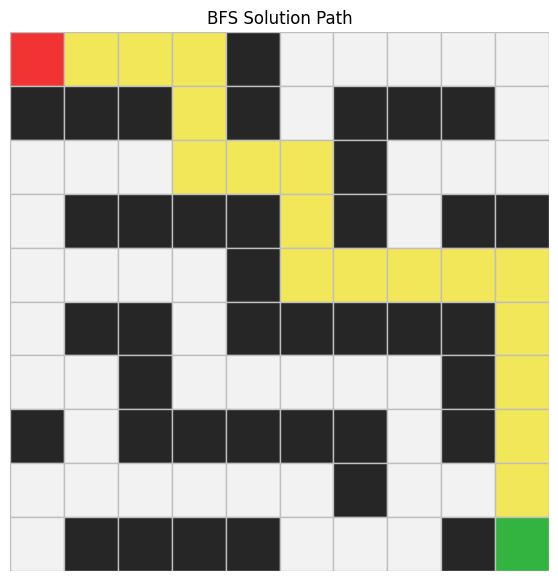

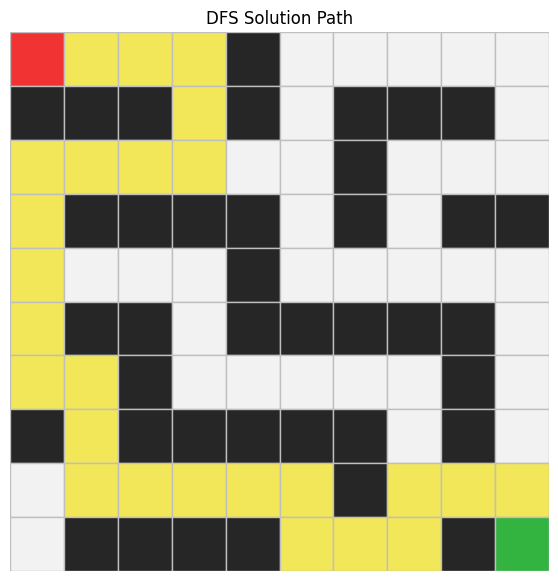

In [42]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [43]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1],
    [1,0,1,1,1,0,1,0,1,1,1,0,1,0,1,1,1,0,1,0],
    [1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0],
    [1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,1,0,1,1,1],
    [1,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0],
    [1,0,1,0,1,0,1,1,1,0,1,0,1,0,1,1,1,0,1,0],
    [1,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0],
    [1,0,1,0,1,0,1,0,1,0,1,1,1,1,1,0,1,1,1,0],
    [1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0],
    [1,0,1,0,1,1,1,0,1,0,1,0,1,0,1,1,1,1,1,0],
    [1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0],
    [1,0,1,1,1,0,1,1,1,1,1,0,1,1,1,1,1,0,1,0],
    [1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0],
    [1,0,1,1,1,0,1,0,1,1,1,1,1,0,1,1,1,1,0,0],
    [1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0],
    [1,1,1,0,1,1,1,1,1,0,1,0,1,0,1,0,1,0,1,0],
    [1,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0],
    [1,0,1,1,1,1,1,1,1,1,1,0,1,0,1,0,1,0,1,0],
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (19, 19)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)


In [44]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,62.0,62.0,88,3,89
1,DFS,success,NaN,62.0,62.0,153,8,154
2,DLS,cutoff,20.0,NaN,NaN,23,21,0
3,IDS,cutoff,40.0,NaN,NaN,944,41,0


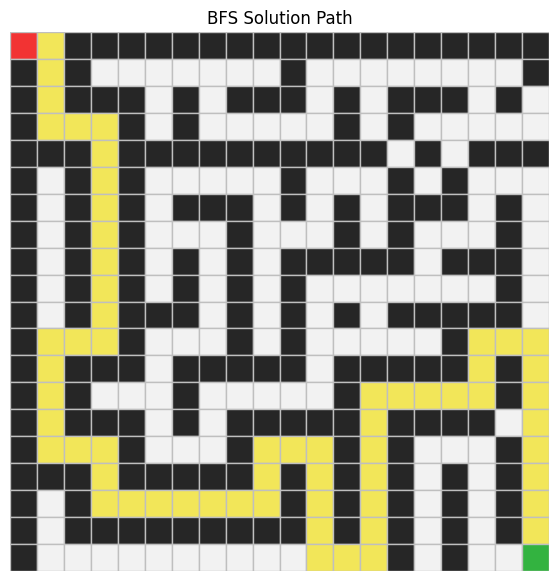

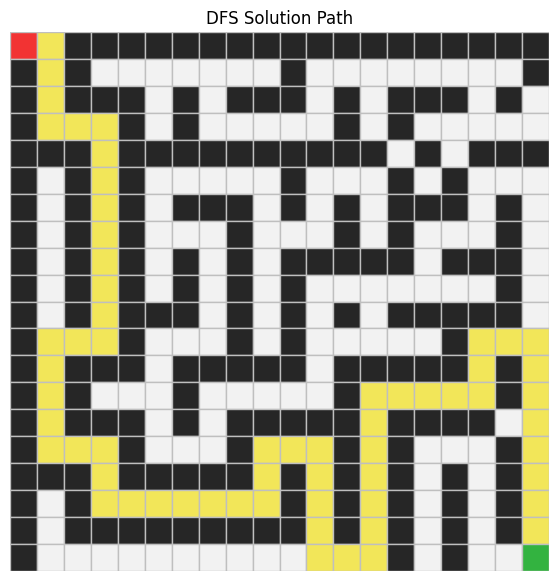

In [45]:
bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dfs_result.path,
    title="DFS Solution Path",)

In [46]:
custom_grid_2 = [
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,1,0,0,0,0,0,0,0,0,0,1],
    [1,1,1,0,1,1,1,1,1,0,1,0,1,0,1],
    [1,0,1,0,1,0,0,0,1,0,1,0,1,0,1],
    [1,0,1,0,1,0,1,0,1,1,1,0,1,1,1],
    [1,0,1,0,0,0,1,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,1,1,1,1,0,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1,0,1,0,1],
    [1,0,1,1,1,0,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,1,0,0,0,0,0,1],
    [1,0,1,1,1,1,1,0,1,1,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,1,0,0,0,1,0,1],
    [1,1,1,1,1,0,1,0,1,0,1,0,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (14, 14)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

In [47]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,32.0,32.0,37,3,39
1,DFS,success,NaN,32.0,32.0,56,5,57
2,DLS,cutoff,20.0,NaN,NaN,20,21,0
3,IDS,success,32.0,32.0,32.0,543,33,0


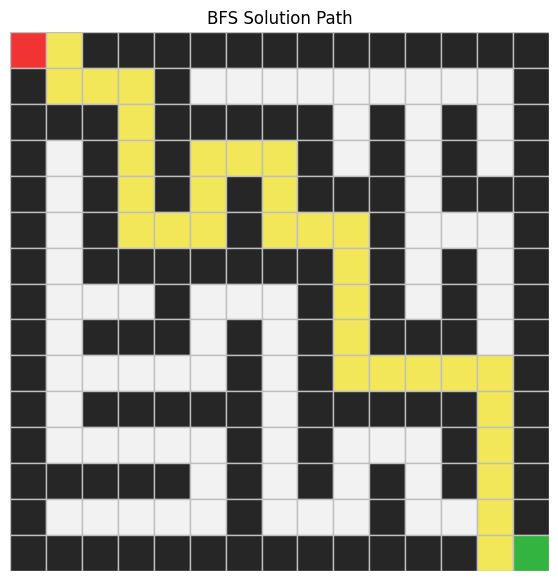

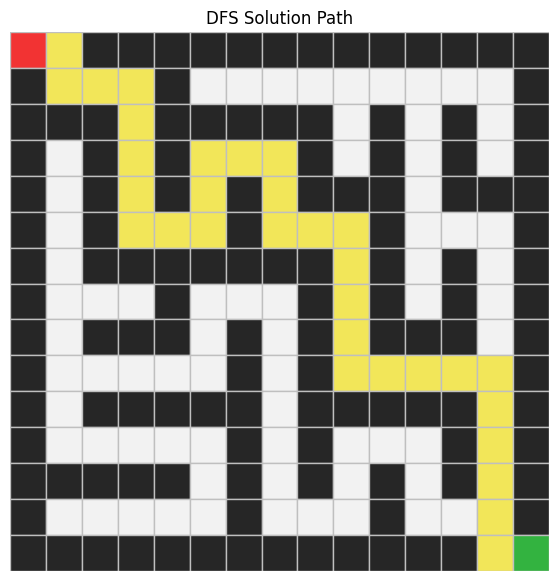

In [48]:
bfs_result = custom_results_2[0]
dfs_result = custom_results_2[1]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dfs_result.path,
    title="DFS Solution Path",)

15.1
1. The state in this lab is a row and column.
2. The actions are the moves(up, down, left, right) taken by the agent.
3. The result function gives the new row and column after taking the action.
4. The same problem can be solved with different algorithms(bfs, dfs, dls, ids)

15.2
1. A FIFO queue allows the BFS to explore all nodes on a single level because the first state added is the first state removed.
2. The path cost for every move is the same (1) so the first time it reaches the goal it is with the shortest possible steps.
3. The reached set stores the state already visited and prevents the BFS from visiting the same state again.

15.3
1. The DFS explores the a single path before trying another. The stack uses last in first out principle which enables the DFS to explore the newest option first.
2. DFS is not guranteed to find the shortest possible path because its focus is just on finding a solution regardless of how long it is.
3. DFS stores only the current path and unexplored branches. However, the BFS stores many nodes at the current which takes a lot of space in memory.
4. A DFS performs badly when there are cycles and it initially takes the worng path or the search space is infinite.

15.4
1. The algorithm will stop before reaching the goal. This is because when the algorithm reaches the limit it stops expanding the nodes.
2. Cutoff - The algorithm stopped because it reached the limit not because it reached the goal.
3. The DFS explores the entire depth to reach the goal. However, the DLS explores the depth but stops when it reaches the limit even if its not the goal.
4. Path cycle prevents the DLS algorithm from revisiting states  on the current path.

15.5
1. The IDS increases the search limit because it does not know how deep the goal.
2. The IDS increases the limit till it gets to the goal but the DLS has a small fixed limit so it may miss the goal.
3. The IDS only stores the curent path and nearby branches but the BFS stores all the nodes at the current level.
4. The extra time it takes to search the root.

15.6
1. A drone will prefer the route with better weather conditions(less air resistance) and better signal strength.
2. The BFS because it checks all paths and uses the shortest possible path before it reaches the goal.
3. The DLS because it  allows to search at a maximum depth.
4. The grid has limited moves and the obstacles and weather conditions are constant or do not exist which is not the same in real time.